# Анализ рынка видеоигр: поиск закономерностей успеха

У нас есть массив исторических данных об индустрии видеоигр: сведения о продажах, оценки критиков и пользователей, жанровая принадлежность и игровые платформы (Xbox, PlayStation и другие). Задача — найти закономерности, которые определяют успех игры на рынке. Это даст возможность делать ставку на перспективные продукты и грамотно выстраивать рекламные кампании.

Данные охватывают период вплоть до 2016 года. Представим, что на дворе декабрь 2016-го, а мы готовим кампанию на 2017 год — именно с этой позиции и будем смотреть на цифры.

В датасете встречается аббревиатура ESRB (Entertainment Software Rating Board) — это организация, которая присваивает компьютерным играм возрастной рейтинг. Она анализирует игровой контент и относит его к подходящей категории: например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

Как будем работать
- Познакомимся с данными и оценим их общую структуру
- Проведём предварительную обработку и подготовку
- Выполним исследовательский анализ и найдём ключевые закономерности
- Составим портрет типичного пользователя для каждого региона
- Проверим статистические гипотезы
- Соберём всё воедино и сформулируем общие выводы

-----------------------------------------------------------------------------------------------------------

### Откроем файл и изучим общую информацию

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [3]:
try:
    data = pd.read_csv('./games.csv')
except:
    print('Ошибка при загрузке датасета', )
else:
    print('Датасет загружен успешно')

Датасет загружен успешно


Выведем первые 10 строк на экран: 

In [4]:
data.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


Выведем общую информацию о датасете:

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


Проверим данные на наличие явных дубликатов:

In [6]:
print(f'Количество дубликатов: {data.duplicated().sum()}')

Количество дубликатов: 0


После знакомства с данными становятся заметны моменты, которые требуют внимания:
- Названия столбцов стоит привести к нижнему регистру — так с ними удобнее работать
- Часть столбцов нужно привести к корректным типам данных
- В некоторых столбцах встречаются пропуски (NaN)
- Имеет смысл добавить новый столбец — суммарные продажи игры по всем регионам

-----------------------------------------------------------------------------------------------------------

### Подготовка данных

Заменим названия столбцов, приведя их к нижнему регистру:

In [7]:
data.columns = data.columns.str.lower()

In [8]:
data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Приведём столбцы с годом выпуска и оценкой критиков к целочисленному типу, так как эти признаки могут принимать только целые значения:

In [9]:
data['year_of_release'] = data['year_of_release'].astype(dtype='Int64').copy()
data['critic_score'] = data['critic_score'].astype(dtype='Int64').copy()

Теперь разберёмся со столбцом user_score. Здесь есть ~2400 строк, в которых значение оценки пользователей заполнено строкой "tbd", что означает "to be decided", то есть оценка подлежит уточнению. Такие значения можно считать пропусками и заполнить их как Nan, чтобы у нас была возможность привести этот столбец к типу float:

In [10]:
data['user_score'] = data['user_score'].replace('tbd', np.nan)

А столбец с оценкой пользователей приведём из типа object в тип float, чтобы у нас была возможность работать с оценкой пользователей как с числом:

In [11]:
data['user_score'] = pd.to_numeric(data['user_score'], errors='coerce')

Теперь посмотрим на количество пропусков:

In [12]:
data.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [13]:
data[data['name'].isna()].head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,<NA>,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,<NA>,NaN,NaN


In [14]:
data.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

Теперь перейдём к столбцу "rating". Возможно, эти пропуски появились вследствие того, что ассоциация ESRB не определила возрастную категорию для данной игры. Такие пропуски можно заменить на значение "Unknown", чтобы было удобнее группировать такие игры без категории в дальнейшем.

In [18]:
data['rating'].fillna(value='Unknown')

0              E
1        Unknown
2              E
3              E
4        Unknown
          ...   
16710    Unknown
16711    Unknown
16712    Unknown
16713    Unknown
16714    Unknown
Name: rating, Length: 16715, dtype: str

In [16]:
data['total_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales'] + data['other_sales']

-----------------------------------------------------------------------------------------------------------

### Исследовательский анализ данных

Сгруппируем данные по году выпуска и посмотрим на количество выпущенных игр:

Text(0.5, 0, 'Год')

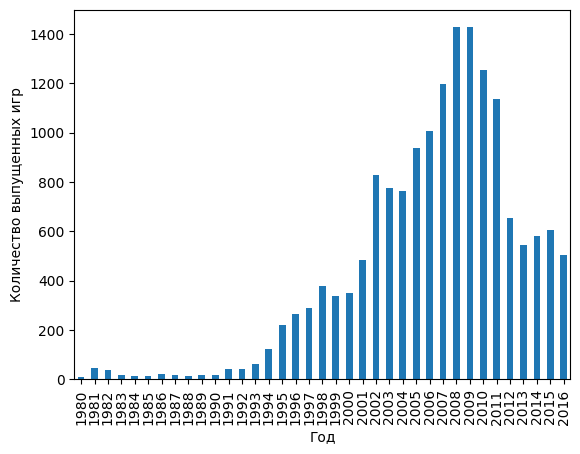

In [17]:
data.groupby('year_of_release')['name'].count().plot(kind='bar')
plt.ylabel('Количество выпущенных игр')
plt.xlabel('Год')

Как мы видим, до 1994 года вышло совсем незначительное количество игр. Всплеск gamedev'а приходится на 2005-2011 годы. <br>
Следовательно, в исследовании нам не так важно учитывать игры, вышедшие до 1994 года.

Посмотрим, как менялись продажи по платформам. Отберём 7 платформ с наибольшими суммарными продажами:

In [19]:
platforms = data.groupby('platform')['total_sales'].sum().sort_values(ascending=False).index[:7]

Text(0.5, 0, 'Год')

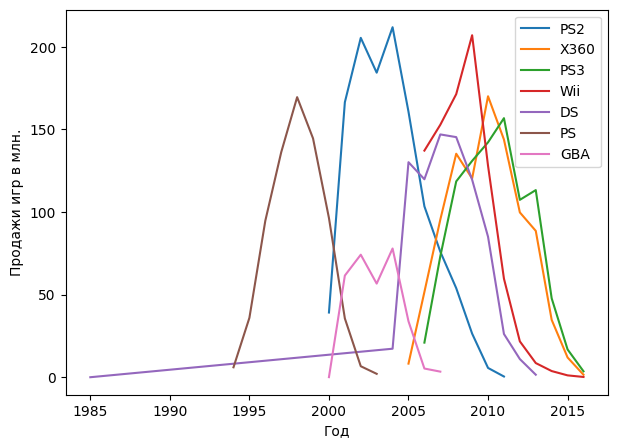

In [21]:
for plaform in platforms:
    data[data['platform']==plaform].groupby('year_of_release')['total_sales'].sum().plot(figsize=(7,5))
plt.legend(platforms)
plt.ylabel('Продажи игр в млн.')
plt.xlabel('Год')

По такому графику можно заметить, что пик популярности платформы **в среднем длится не более 5 лет**, после чего появляется новая платформа и сменяет предыдущую <br>
Теперь посмотрим на средний полный жизненный срок существования консоли:

In [22]:
platform = data.groupby('platform')['year_of_release'].agg(['min', 'max'])
print(f"Средний полный жизненный срок существования консоли: {'%.2f'%(platform['max']-platform['min']).mean()} лет")

Средний полный жизненный срок существования консоли: 7.61 лет


В качестве актуального периода для прогнозирования на 2017 год можно выбрать **данные за 2013-2016 годы**, так как эти данные всё ещё актуальны (особенно учитывая тот факт, что индустрия компьютерных игр достаточно быстро меняется)

-----------------------------------------------------------------------------------------------------------

Посмотрим, какие плафтормы лидируют в этом актуальном периоде по продажам:

In [23]:
actual_data = data[data['year_of_release']>=2013]

Text(0.5, 0, 'Год')

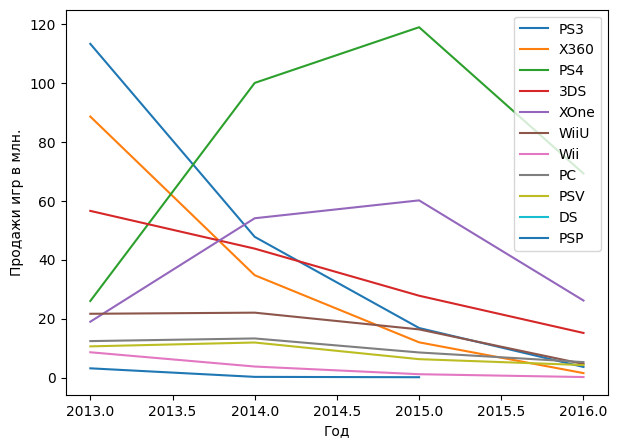

In [24]:
for plaform in actual_data['platform'].unique():
    actual_data[actual_data['platform']==plaform].groupby('year_of_release')['total_sales'].sum().plot(figsize=(7,5))
plt.legend(list(actual_data['platform'].unique()))
plt.ylabel('Продажи игр в млн.')
plt.xlabel('Год')

Как мы видим, по продажам игр сейчас лидируют платформы нового поколения (на 2016 год): это PS4 и Xbox One. Популярные платформы прошлого поколения уже почти упали в продажах по играм. К таким относятся платформы PS3, Xbox 360 и Nintendo 3ds

[Text(0.5, 0, 'Платформа'), Text(0, 0.5, 'Общий объём продаж игры в млн.')]

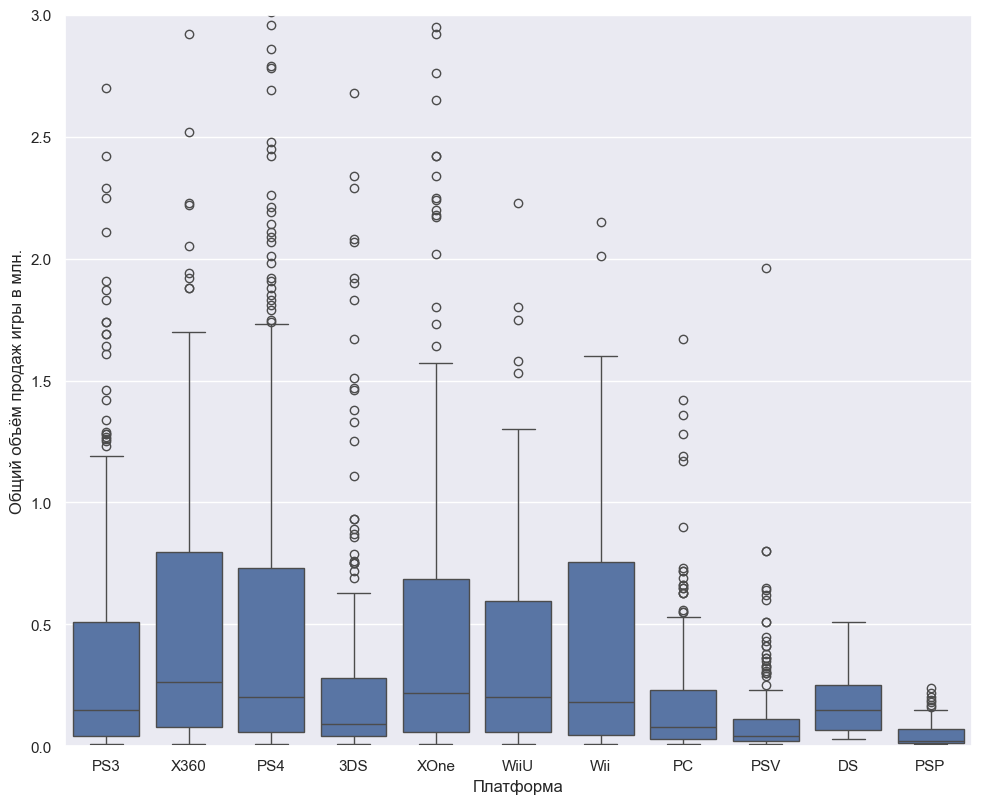

In [26]:
sns.set(rc={'figure.figsize':(11.7,9.5)})
plt.ylim(0, 3)
sns.boxplot(x=actual_data["platform"], y=actual_data['total_sales']).set(xlabel='Платформа', ylabel='Общий объём продаж игры в млн.')

Отсюда мы можем увидеть, какую игру можно считать популярной в зависимости от общего объёма её продаж. <br>
Так, например, для платформы PS3 популярными можно считать те игры, суммарный объём продаж которых превысил 1.25 миллиона копий, когда в среднем продаётся примерно 150 тысяч копий игры <br>
Для платформ Xbox 360 и PS4 популярными можно считать те игры, суммарный объём продаж которых превысил 1.75 миллиона копий

-----------------------------------------------------------------------------------------------------------

Теперь посмотрим, как внутри платформы PS4 на продажу игр влияют отзывы критиков и пользователей:

In [27]:
ps4_data = actual_data[(actual_data['platform']=='PS4')]

Text(0.5, 0, 'Оценка критиков')

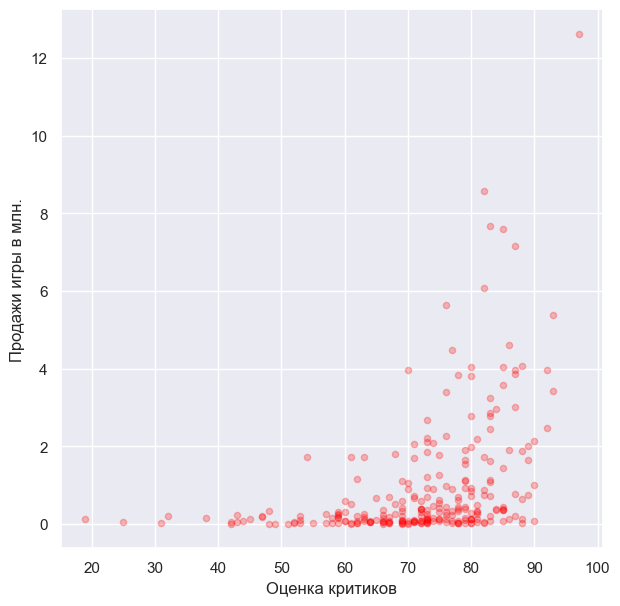

In [28]:
sns.set(rc={'figure.figsize':(7, 7)})
ps4_data.plot.scatter(x='critic_score', y="total_sales", alpha=0.25, c='red')
plt.ylabel('Продажи игры в млн.')
plt.xlabel('Оценка критиков')

In [29]:
ps4_data['critic_score'].astype(dtype='float').corr(ps4_data['total_sales'])

np.float64(0.40656790206178095)

Как мы видим, оценка критиков действительно влияет на объём продаж игры. Имеется небольшая слабая линейная связь: как правило, чем выше оценка критиков, тем больше у игры продажи

Text(0.5, 0, 'Оценка пользователей')

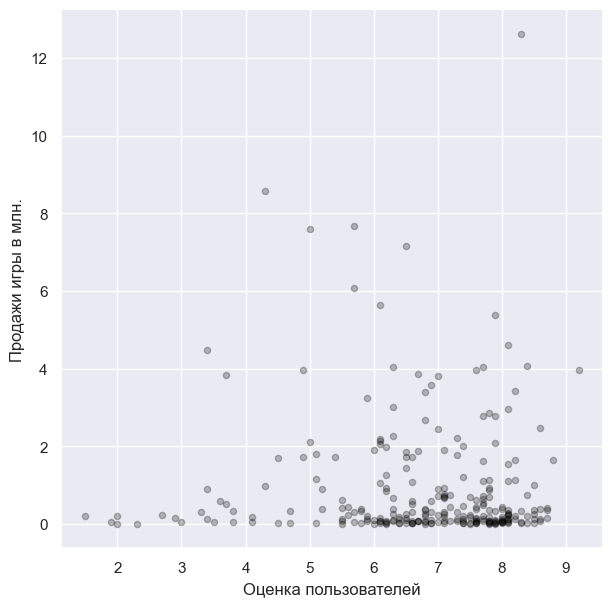

In [30]:
ps4_data.plot.scatter(x='user_score', y="total_sales", alpha=0.25, c='black')
plt.ylabel('Продажи игры в млн.')
plt.xlabel('Оценка пользователей')

In [31]:
ps4_data['user_score'].corr(ps4_data['total_sales'])

np.float64(-0.03195711020455645)

А вот оценка пользователей, как оказалось, почти не влияет на объёмы продаж самой игры (линейный коэффициент корреляции близок к нулю)

-----------------------------------------------------------------------------------------------------------

Соотнесём выводы с продажами игр на других платформах:

In [47]:
print('Платформа\t Критики\tПользователи \t Количество игр')

for platform in actual_data['platform'].unique():
    platform_data = actual_data[actual_data['platform'] == platform]

    critic_data = platform_data.dropna(subset=['critic_score', 'total_sales'])
    if len(critic_data) >= 2:
        corr_critic = critic_data['critic_score'].astype(float).corr(critic_data['total_sales'])
        corr_critic_str = f"{corr_critic:.2f}"
    else:
        corr_critic_str = "N/A"

    user_data = platform_data.dropna(subset=['user_score', 'total_sales'])
    if len(user_data) >= 2:
        corr_user = user_data['user_score'].astype(float).corr(user_data['total_sales'])
        corr_user_str = f"{corr_user:.2f}"
    else:
        corr_user_str = "N/A"
    
    print(f'{platform}:\t\t {corr_critic_str} \t\t{corr_user_str} \t\t {len(platform_data)}')

Платформа	 Критики	Пользователи 	 Количество игр
PS3:		 0.33 		0.00 		 345
X360:		 0.35 		-0.01 		 186
PS4:		 0.41 		-0.03 		 392
3DS:		 0.36 		0.24 		 303
XOne:		 0.42 		-0.07 		 247
WiiU:		 0.38 		0.42 		 115
Wii:		 N/A 		0.68 		 23
PC:		 0.20 		-0.09 		 189
PSV:		 0.25 		0.00 		 358
DS:		 N/A 		N/A 		 8
PSP:		 N/A 		-1.00 		 67


Оказалось, что такая ситуация, как на PS4, наблюдается почти везде, за исключением некоторых платформ, где оценок критиков или пользователей было недостаточно. Данные по платформе PS2 учитывать не стоит из-за небольшого количества вышедших игр.

-----------------------------------------------------------------------------------------------------------

Теперь посмотрим на распределение игр по жанрам:

Text(0.5, 0, 'Жанр')

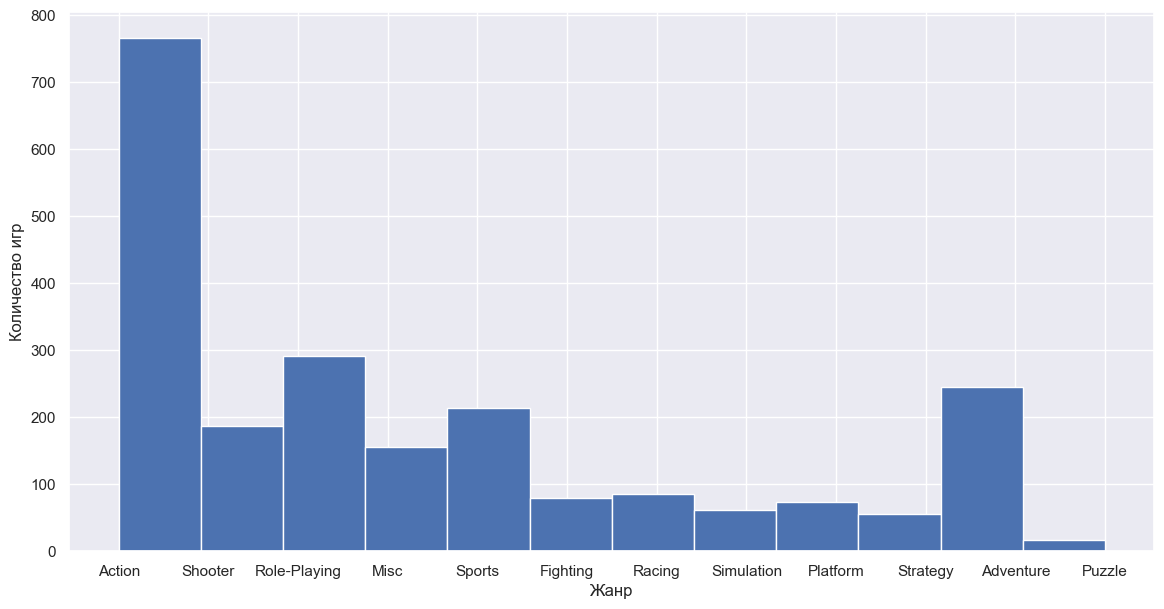

In [33]:
sns.set(rc={'figure.figsize':(14, 7)})
actual_data['genre'].hist(bins=12)
plt.ylabel('Количество игр')
plt.xlabel('Жанр')

Как мы видим, самым популярным жанром с большим отрывом от других является "Экшен"

-----------------------------------------------------------------------------------------------------------

Посмотрим на самые прибыльные жанры:

[Text(0.5, 0, 'Жанр'), Text(0, 0.5, 'Общий объём продаж игры в млн.')]

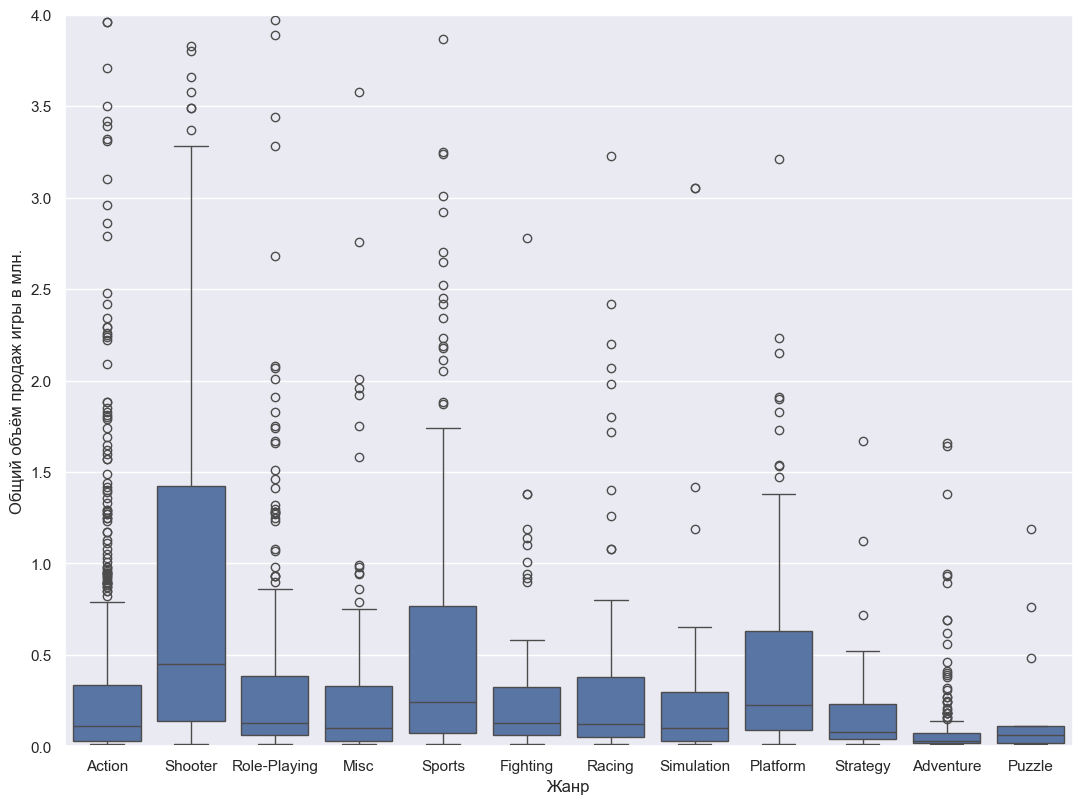

In [34]:
sns.set(rc={'figure.figsize':(13,9.5)})
plt.ylim(0, 4)
sns.boxplot(x=actual_data["genre"], y=actual_data['total_sales']).set(xlabel='Жанр', ylabel='Общий объём продаж игры в млн.')

Оказалось, что самые популярные жанры необязательно приносят самый большой доход в среднем <br>
Так, например, несмотря на то, что в жанре Action было выпущено наибольшее количество игр, средние продажи в этом жанре в 5 раз меньше, чем в жанре Shooter <br>
Можно выделить явных лидеров по средним продажам:
1. Shooter - 500 тысяч копий
2. Sports - 300 тысяч копий
3. Platform - 250 тысяч копий <br>

Таким образом, можно сделать вывод: большое количество выпущенных игр в определённом жанре необязательно говорит о том, что этот жанр будет наиболее прибыльным

-----------------------------------------------------------------------------------------------------------

### Составим портрет пользователя каждого региона

#### Регион NA
Посмотрим на топ-5 популярных платформ:

Text(0.5, 0, 'Платформа')

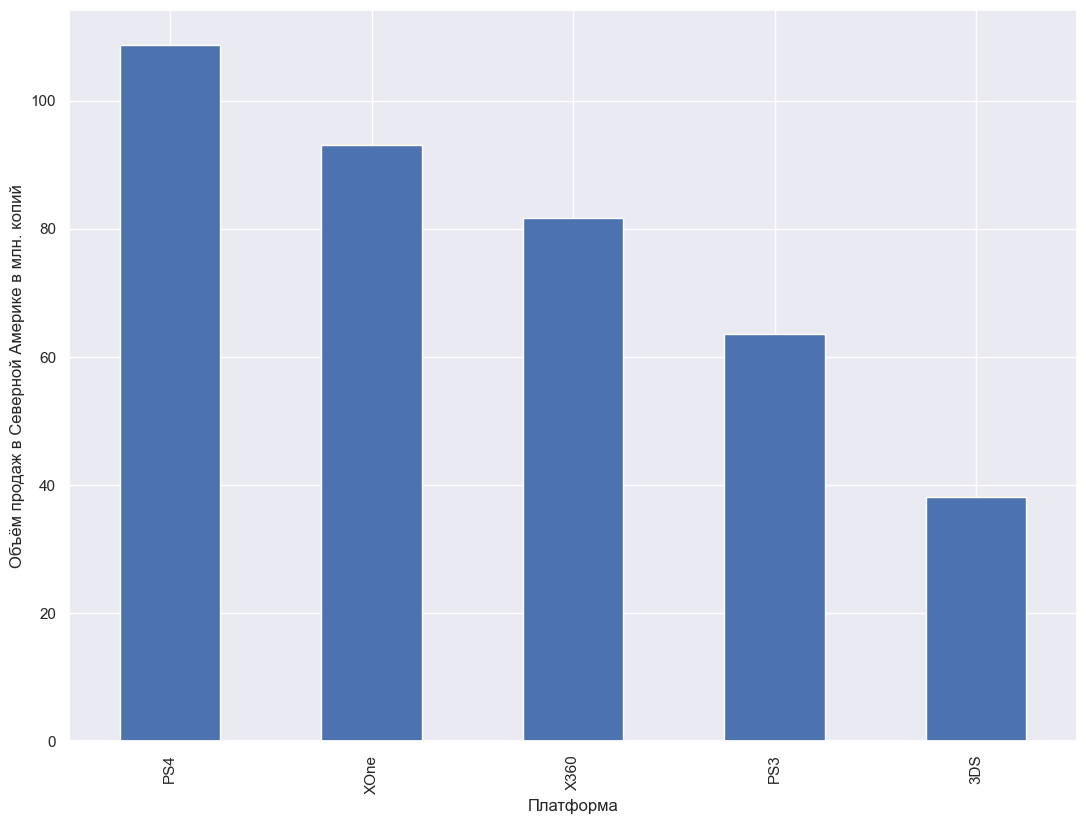

In [37]:
actual_data.groupby('platform')['na_sales'].sum().\
sort_values(ascending=False).head(5).plot.bar()
plt.ylabel('Объём продаж в Северной Америке в млн. копий')
plt.xlabel('Платформа')

В Северной Америке на период 2013-2016 годов самыми популярными платформами ещё являлись платформы прошлого поколения, то есть Xbox 360 и PS3, а весь рынок, можно сказать, разделяют между собой Xbox и PlayStation. Nintendo с платформой 3DS занимает лишь 5-ое место

Топ-5 популярных жанров:

Text(0.5, 0, 'Жанр')

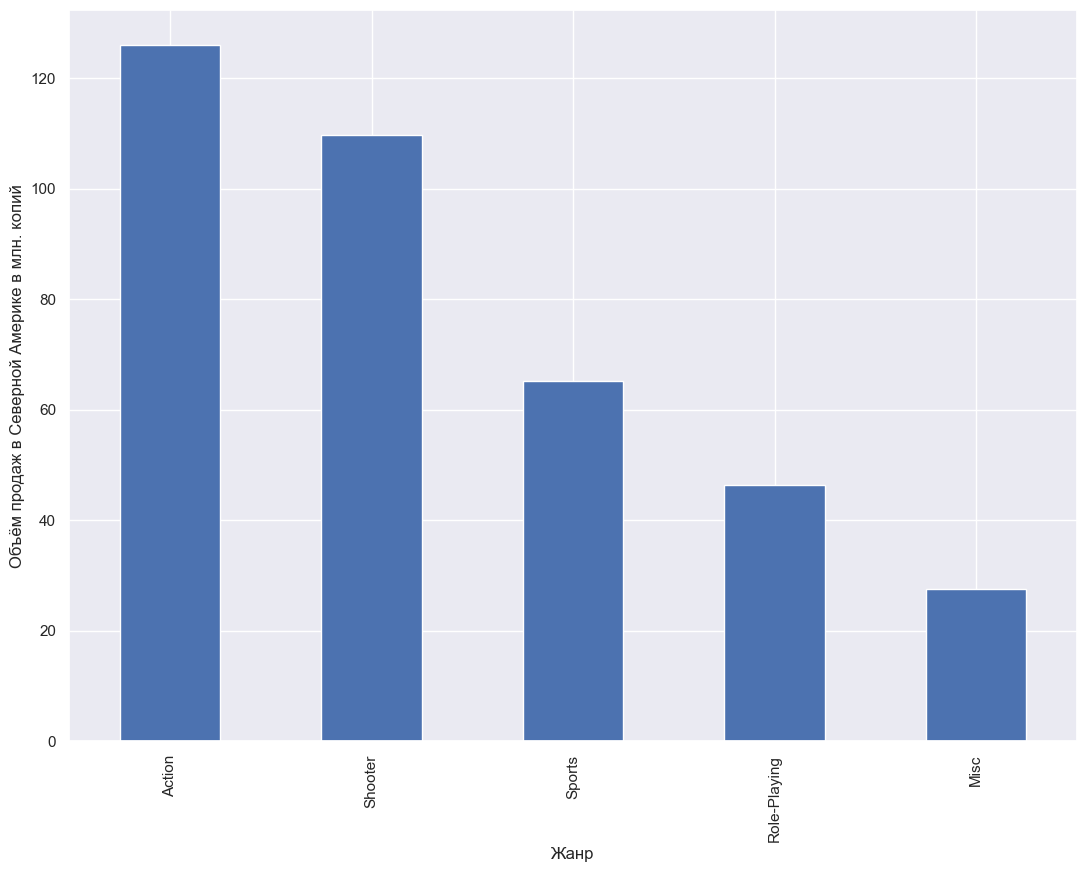

In [38]:
actual_data.groupby('genre')['na_sales'].sum().\
sort_values(ascending=False).head(5).plot.bar()
plt.ylabel('Объём продаж в Северной Америке в млн. копий')
plt.xlabel('Жанр')

В Северной Америке лидируют жанры Action и Shooter с объёмами продаж в 200 млн. копий, затем идут жанры Sports (~100 млн. копий), Role-playing и Miscellaneous (менее 100 млн. копий)

Влияние рейтинга ESRB на продажи:

Text(0.5, 0, 'Рейтинг ESRB')

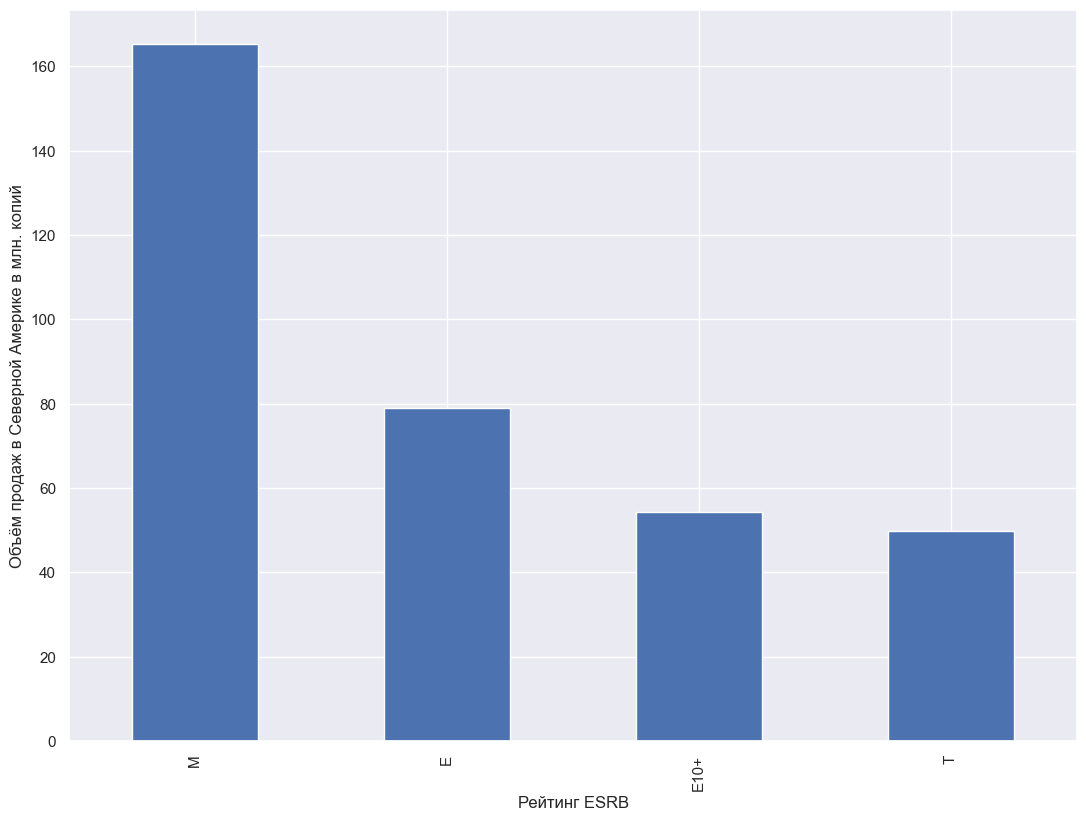

In [39]:
actual_data.groupby('rating')['na_sales'].sum().sort_values(ascending=False).plot.bar()
plt.ylabel('Объём продаж в Северной Америке в млн. копий')
plt.xlabel('Рейтинг ESRB')

Как мы видим, количество продаж в NA действительно в какой-то степени связано с рейтингом ESRB. Так, самыми продаваемыми являются игры с рейтингом M (17+). Игры с рейтингами E(6+), E10+(10+) и T(13+) и вообще без рейтинга продаются значительно меньше.

-----------------------------------------------------------------------------------------------------------

#### Регион EU
**Посмотрим на топ-5 популярных платформ:**

Text(0.5, 0, 'Платформа')

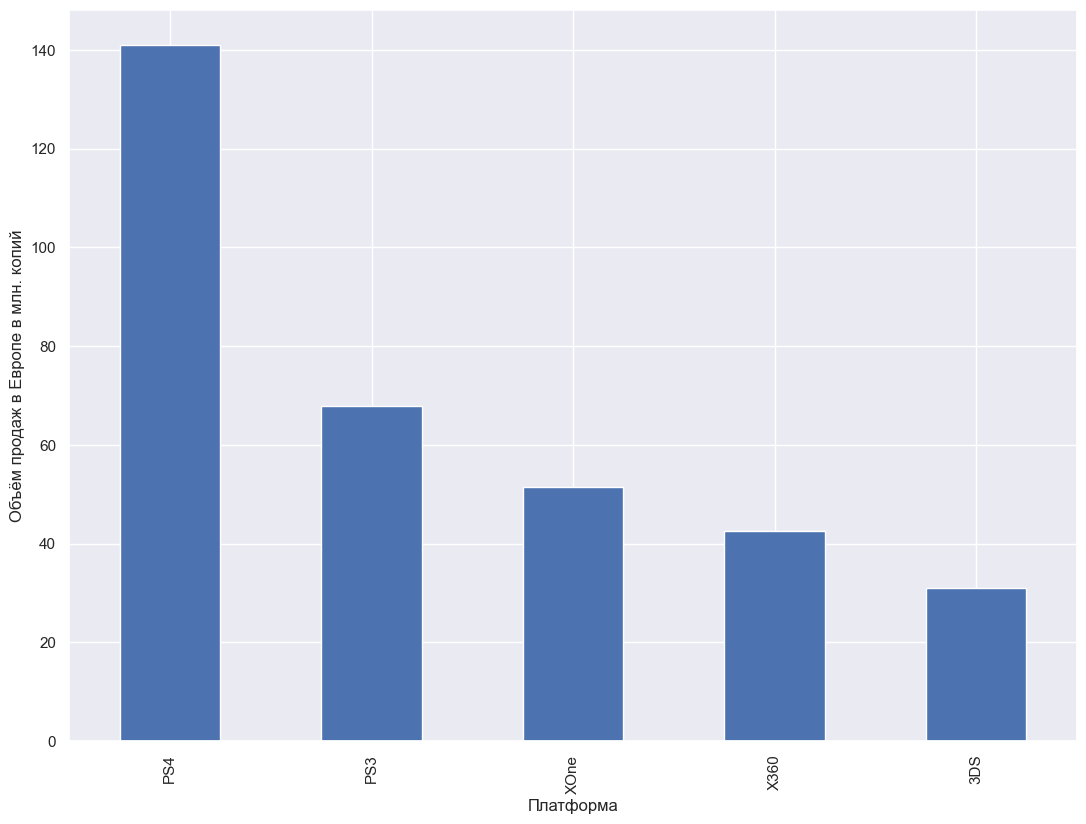

In [40]:
actual_data.groupby('platform')['eu_sales'].sum().\
sort_values(ascending=False).head(5).plot.bar()
plt.ylabel('Объём продаж в Европе в млн. копий')
plt.xlabel('Платформа')

В Европе на момент 2016 года самой популярной платформой является PlayStation (PS3 и PS4 продали суммарно 300 млн. копий), когда Xbox360 занимает лишь третье место (а Xbox One и вовсе нет в топе). Также европейские геймеры предпочитают Nintendo 3DS и PC (по ~60 млн. копий)

Топ-5 популярных жанров:

Text(0.5, 0, 'Жанр')

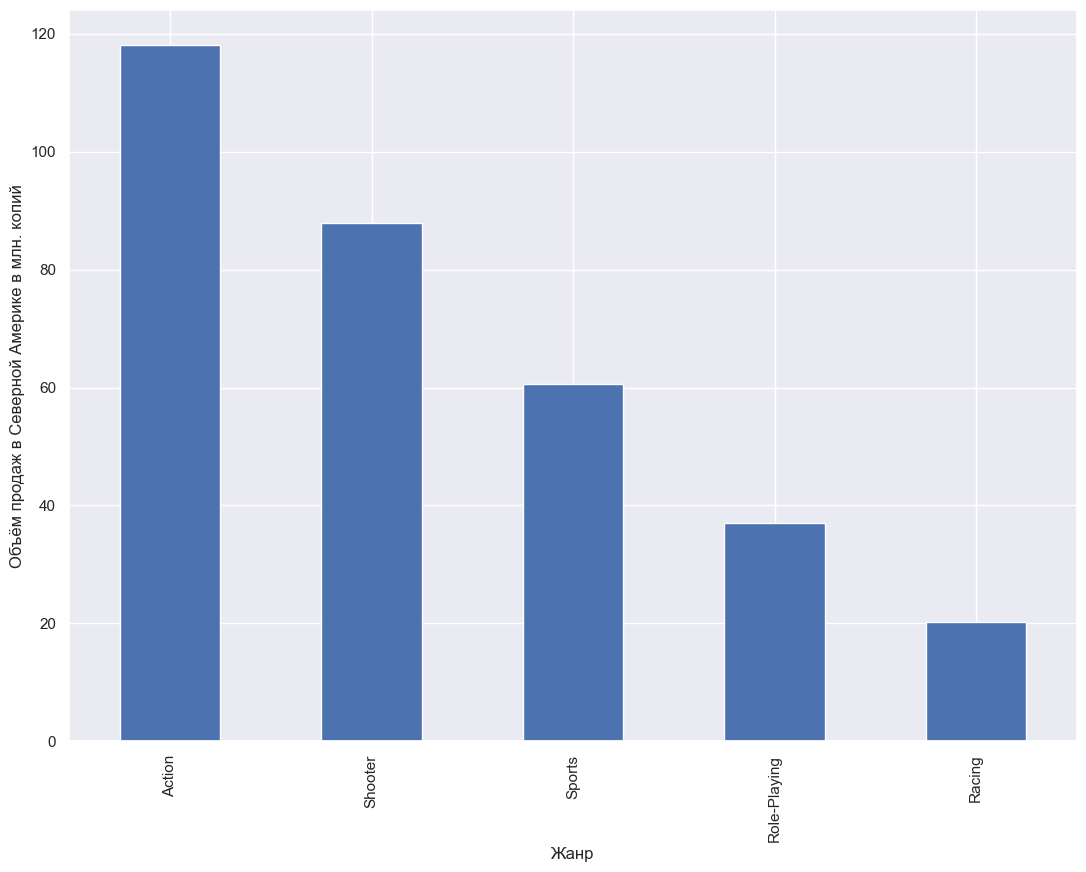

In [44]:
actual_data.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5).plot.bar()
plt.ylabel('Объём продаж в Северной Америке в млн. копий')
plt.xlabel('Жанр')

В Европе лидирующие жанры почти не отличаются от топ-жанров Северной Америки. Единственное отличие в топ-5 заключается в том, что европейцы предпочитают гонки (5-ое место)

Влияние рейтинга ESRB на продажи:

Text(0.5, 0, 'Рейтинг ESRB')

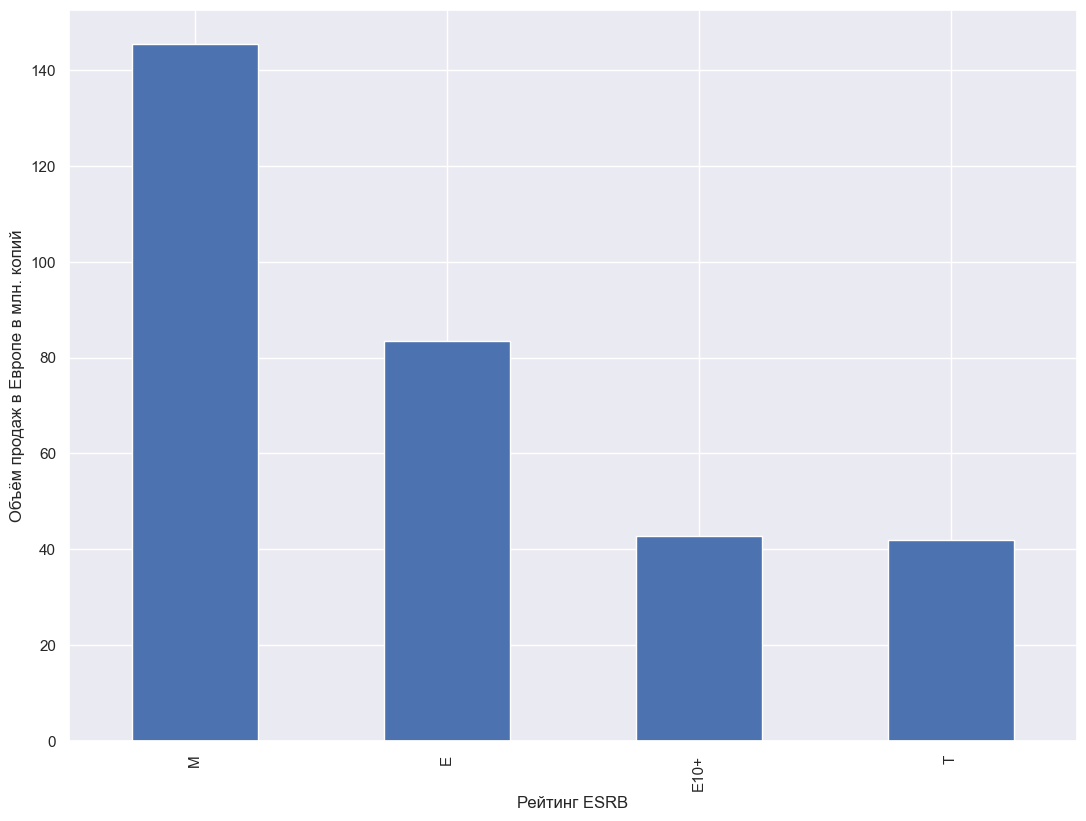

In [42]:
actual_data.groupby('rating')['eu_sales'].sum().sort_values(ascending=False).plot.bar()
plt.ylabel('Объём продаж в Европе в млн. копий')
plt.xlabel('Рейтинг ESRB')

Рейтинг ESRB влияет на продажи игр почти так же, как и в Северной Америке. Однако стоит отметить, что в Европе чуть чаще продаются игры с рейтингом E(6+)

-----------------------------------------------------------------------------------------------------------

#### Регион JP
Посмотрим на топ-5 популярных платформ:

Text(0.5, 0, 'Платформа')

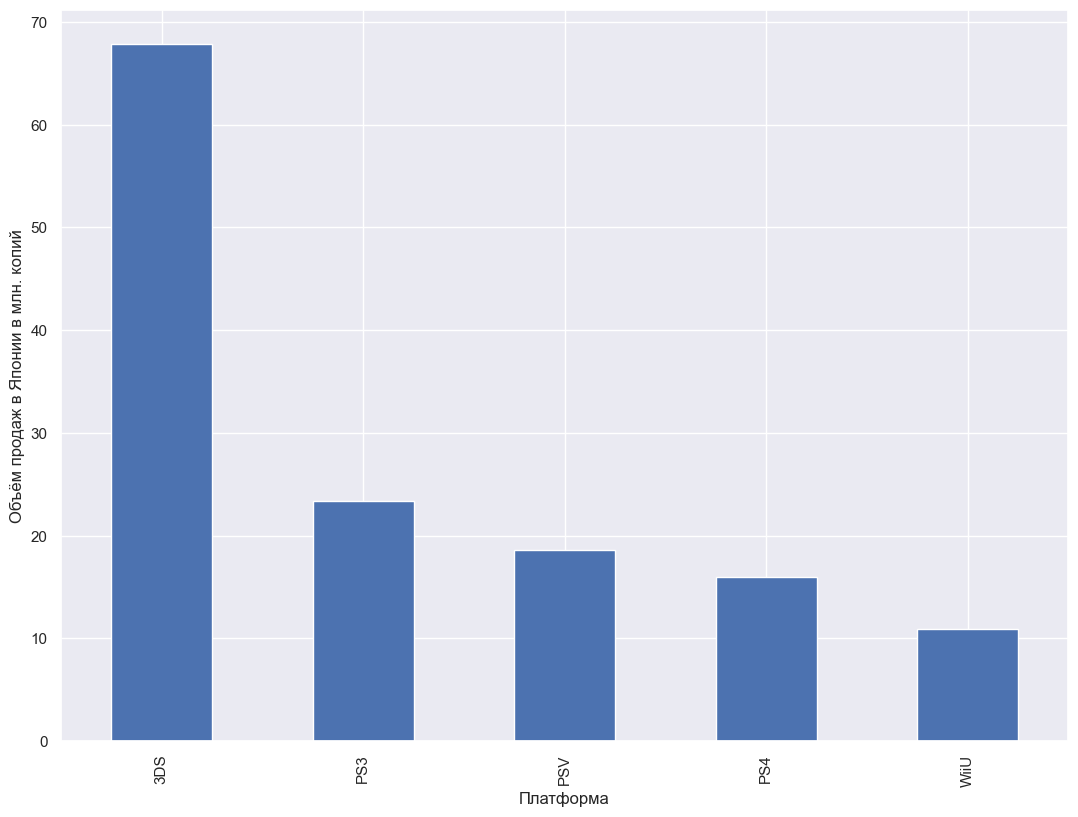

In [43]:
actual_data.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5).plot.bar()
plt.ylabel('Объём продаж в Японии в млн. копий')
plt.xlabel('Платформа')

На рынке Японии ситуация сильно отличается: абсолютным лидером рынка на 2016 год является отечественная компания Nintendo с платформой 3DS. Оставшиеся 4 позиции занимает японский производитель PlayStation.

Топ-5 популярных жанров:

Text(0.5, 0, 'Жанр')

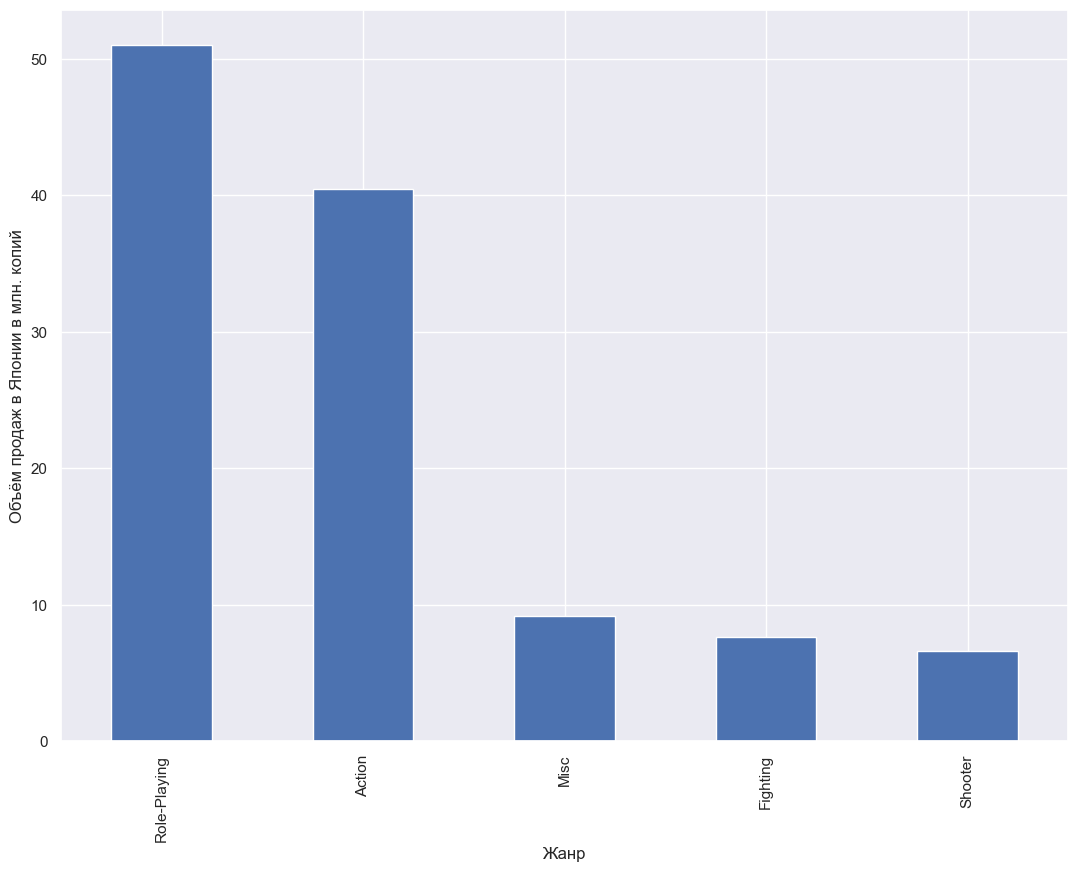

In [45]:
actual_data.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5).plot.bar()
plt.ylabel('Объём продаж в Японии в млн. копий')
plt.xlabel('Жанр')

Ситуация с жанрами тоже очень сильно изменилась: геймеры Японии предпочитают жанру "Экшен" ролевые игры (80 млн. проданных копий), а на оставшихся трёх местах находятся жанры Misc, Fighting и Platform

Влияние рейтинга ESRB на продажи:

Text(0.5, 0, 'Рейтинг ESRB')

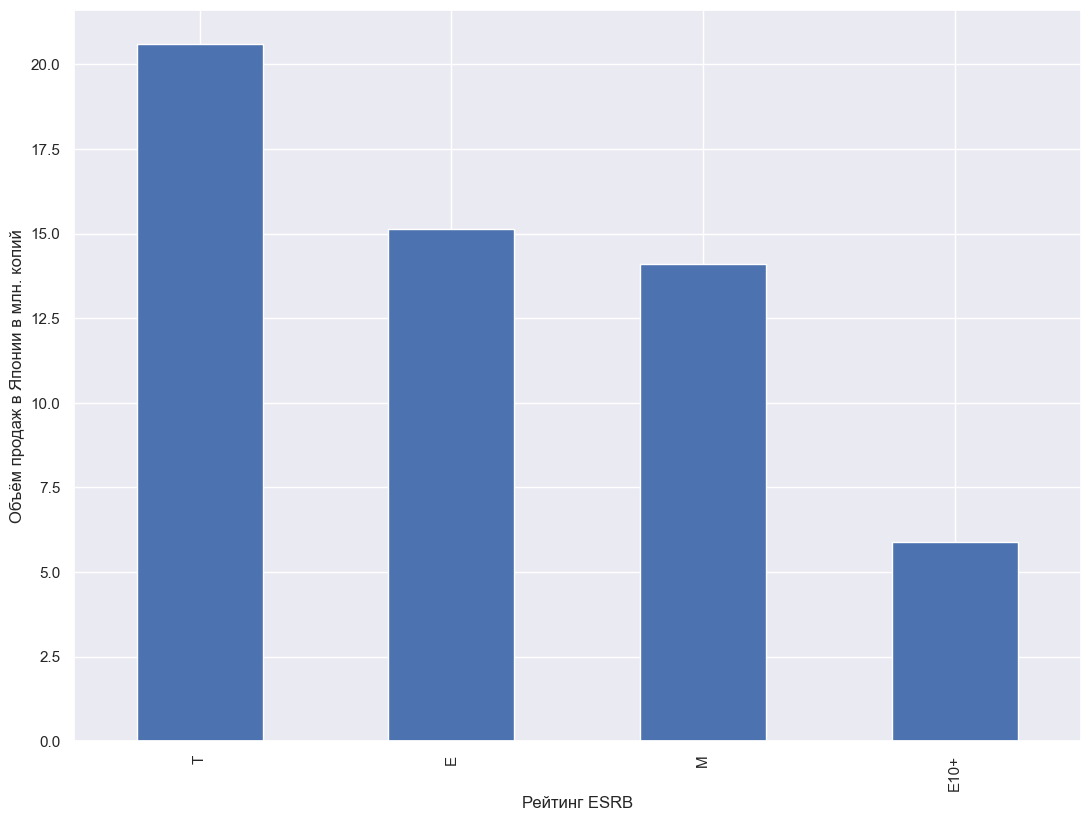

In [46]:
actual_data.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).plot.bar()
plt.ylabel('Объём продаж в Японии в млн. копий')
plt.xlabel('Рейтинг ESRB')

Оказалось, что в Японии любят игры без насилия и грубой жестокости: об этом говорят высокие продажи игр с рейтингом E и T, на которые приходится примерно 70 млн. проданных копий
А ещё больше предпочитают игры, которым вообще не присвоили рейтинг ESRB. Таких игр абсолютное подавляющее большинство.

-----------------------------------------------------------------------------------------------------------

### Проверяем гипотезы

Первая гипотеза звучит так: "Средние пользовательские рейтинги жанров Action и Sports разные" <br>
**Нулевая гипотеза**: Средний пользовательский рейтинг жанра Action равен среднему пользовательскому рейтингу жанра Sports <br>
**Альтернативная гипотеза**: Средний пользовательский рейтинг жанра Action не равен среднему пользовательскому рейтингу жанра Sports

In [48]:
action = actual_data.query('genre=="Action"')['user_score']
sports = actual_data[(actual_data['genre']=='Sports') & (~actual_data['user_score'].isna())]['user_score']

Мы проверяем гипотезу о равенстве средних двух генеральных совокупностей, поэтому используем ttest_ind() с параметром equal_var=False, так как дисперсии двух генеральных совокупностей в данном случае могут значительно отличаться:

In [49]:
results = st.ttest_ind(action, sports, equal_var=False)
alpha = 0.05

print(f'P-Value = {results.pvalue}')
if results.pvalue>alpha:
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print('Отвергаем нулевую гипотезу')

P-Value = nan
Отвергаем нулевую гипотезу


In [50]:
print(f'Средний пользовательский рейтинг жанра Action: {"%.2f"%action.mean()}')
print(f'Средний пользовательский рейтинг жанра Sports: {"%.2f"%sports.mean()}')

Средний пользовательский рейтинг жанра Action: 6.84
Средний пользовательский рейтинг жанра Sports: 5.24


Отсюда мы также можем подтвердить, что средние пользовательские рейтинги жанров Action и Sports разные

-----------------------------------------------------------------------------------------------------------

Первая гипотеза звучит так: "Средние пользовательские рейтинги платформ Xbox One и PC одинаковые" <br>
**Нулевая гипотеза**: Средний пользовательский рейтинг платформы Xbox One равен среднему пользовательскому рейтингу платформы PC <br>
**Альтернативная гипотеза**: Средний пользовательский рейтинг платформы Xbox One не равен среднему пользовательскому рейтингу платформы PC

In [52]:
xbox = actual_data.query('platform=="XOne"')['user_score']
pc = actual_data.query('platform=="PC"')['user_score']

Мы проверяем гипотезу о равенстве средних двух независимых генеральных совокупностей, поэтому используем ttest_ind():

In [53]:
results = st.ttest_ind(xbox, pc, equal_var=True)
alpha = 0.05

print(f'P-Value = {results.pvalue}')
if results.pvalue>alpha:
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print('Отвергаем нулевую гипотезу')

P-Value = nan
Отвергаем нулевую гипотезу


In [54]:
print(f'Средний пользовательский рейтинг на Xbox One: {"%.2f"%xbox.mean()}')
print(f'Средний пользовательский рейтинг на PC: {"%.2f"%pc.mean()}')

Средний пользовательский рейтинг на Xbox One: 6.52
Средний пользовательский рейтинг на PC: 6.27


Отсюда мы так же можем подтвердить, что средние пользовательские рейтинги платформ Xbox One и PC почти не отличаются, то есть одинаковы

-----------------------------------------------------------------------------------------------------------

### Общий вывод

Чтобы понять, что именно определяет успех игры в 2017 году, мы провели предобработку данных о продажах и пришли к выводу: рассматривать стоит только последние четыре года — с 2013 по 2016-й. Такой период позволяет уловить актуальные тенденции и не тянуть за собой устаревшие.

Что показало исследование:
- На смену старым платформам (Xbox 360, PS3 и 3DS) приходят консоли нового поколения (PS4 и Xbox One), которые стремительно набирают популярность. Именно они сейчас лидируют по суммарным продажам игр.
- Для PS4 и Xbox One успешными можно считать игры, чьи мировые продажи перевалили за 1,75 млн копий.
- Высокие оценки критиков почти на всех платформах положительно сказываются на продажах (исключения разберём отдельно в соответствующем разделе). А вот пользовательские оценки на продажи практически не влияют (за возможным исключением WiiU).
- Самые востребованные и прибыльные жанры: шутеры, спортивные симуляторы и платформеры.
- Большое число выпущенных игр в жанре вовсе не гарантирует, что жанр окажется самым доходным.
- У каждого рынка (Северной Америки, Европы и Японии) свои характерные особенности, и их обязательно учитывать при планировании рекламных кампаний (подробнее в п. 5).
- Есть основания предполагать, что пользовательский рейтинг игры почти не различается от платформы к платформе.